In [1]:
from pathlib import Path
import time

import halo_shape_functions as hsf

import matplotlib.pyplot as plt

import pandas as pd

In [2]:
# Base folder 
base_path = Path("data")

# using wsi_analysis_demo.svs
image_location = base_path / "wsi_analysis_demo.svs"
annotation_file = base_path / "wsi_analysis_demo.annotations"

# using 'unbiased' example
unb_image_location = base_path / "wsi_unbiased_analysis_demo.svs"
unb_annotation_file = base_path / "wsi_unbiased_analysis_demo.annotations"

# Output folder
out_dir = Path("parameter_sweep")
out_dir.mkdir(exist_ok=True)

In [3]:
# Define annotation layer names used in the annotation files
tumor_layer = 'tumor'
tissue_layer = 'tissue'
calibration_layer = 'calib'

In [4]:
# Parse layers into MultiPolygons
tumor_poly = hsf.parse_annotation_file(tumor_layer, annotation_file)
tissue_poly = hsf.parse_annotation_file(tissue_layer, annotation_file)
calib_layer = hsf.parse_annotation_file(calibration_layer, annotation_file)

#Bounding box rectangle around all polygons for image polygon overlays
outer_geom = tissue_poly.envelope

In [5]:
# Parse tissue and calibration layers
unb_tissue_poly = hsf.parse_annotation_file(tissue_layer, unb_annotation_file)
unb_calib_layer = hsf.parse_annotation_file(calibration_layer, unb_annotation_file)
# unb_tumor_poly = hsf.parse_annotation_file(tumor_layer, unb_annotation_file) # no tumor annotation layer

unb_outer_geom = unb_tissue_poly.envelope

## Visualize Different Masks
Taking a look at how the tumor mask and the two tissue masks differ from one another.

### Tumor Mask

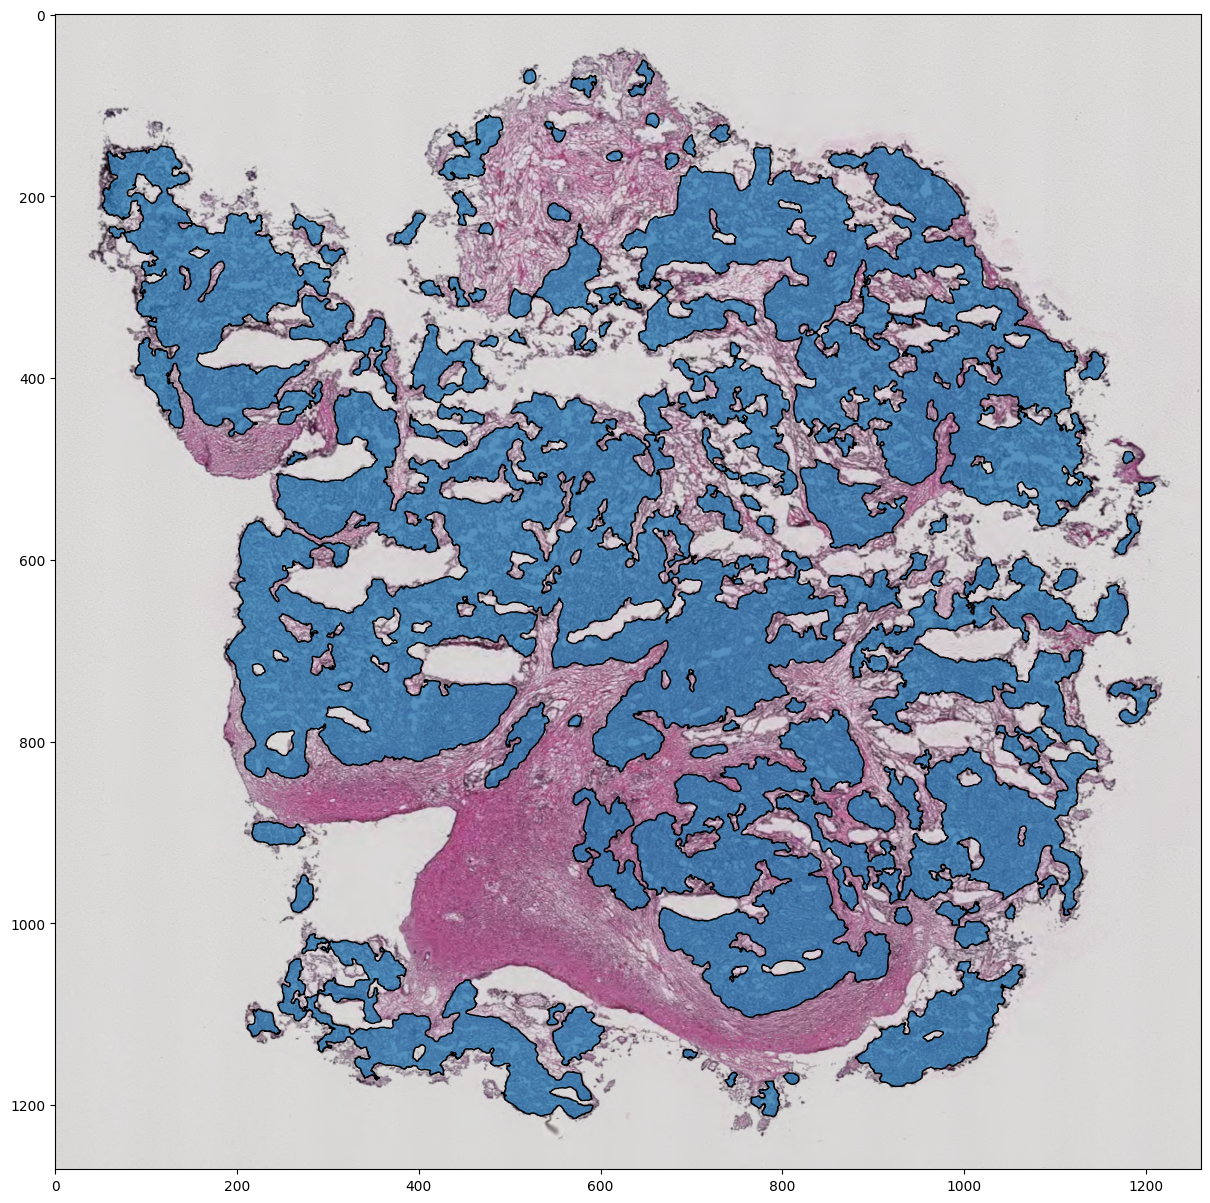

In [6]:
ret = hsf.plot_shapes_onto_tissue(tumor_poly, image_location, tissue_poly)

### Tissue Mask (from the tissue with a tumor mask)

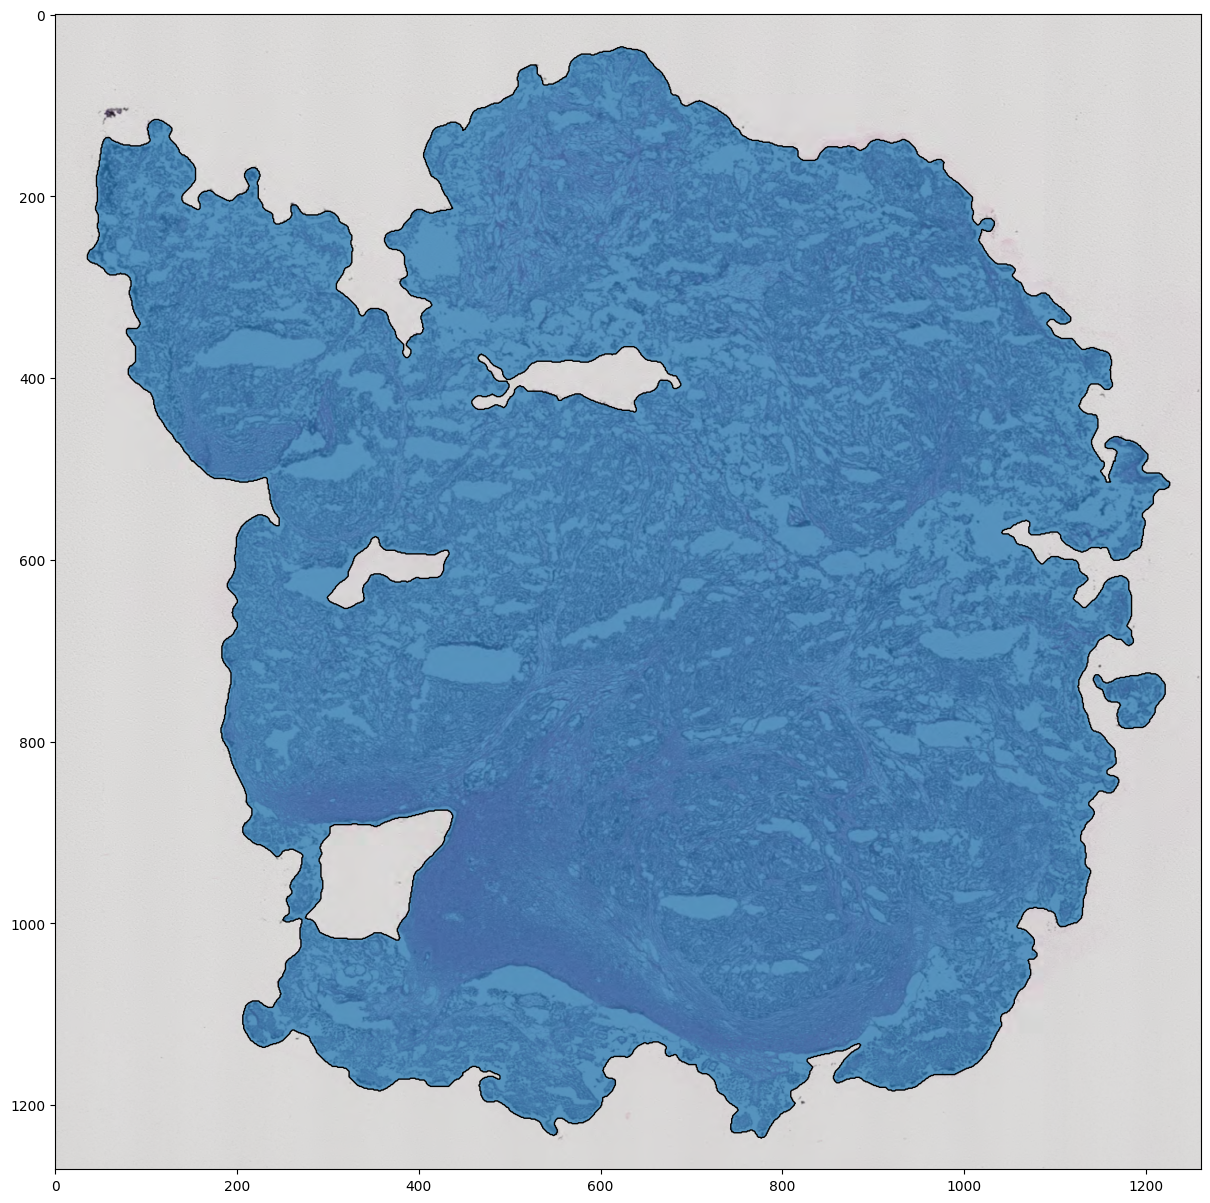

In [7]:
ret = hsf.plot_shapes_onto_tissue(tissue_poly, image_location, tissue_poly)

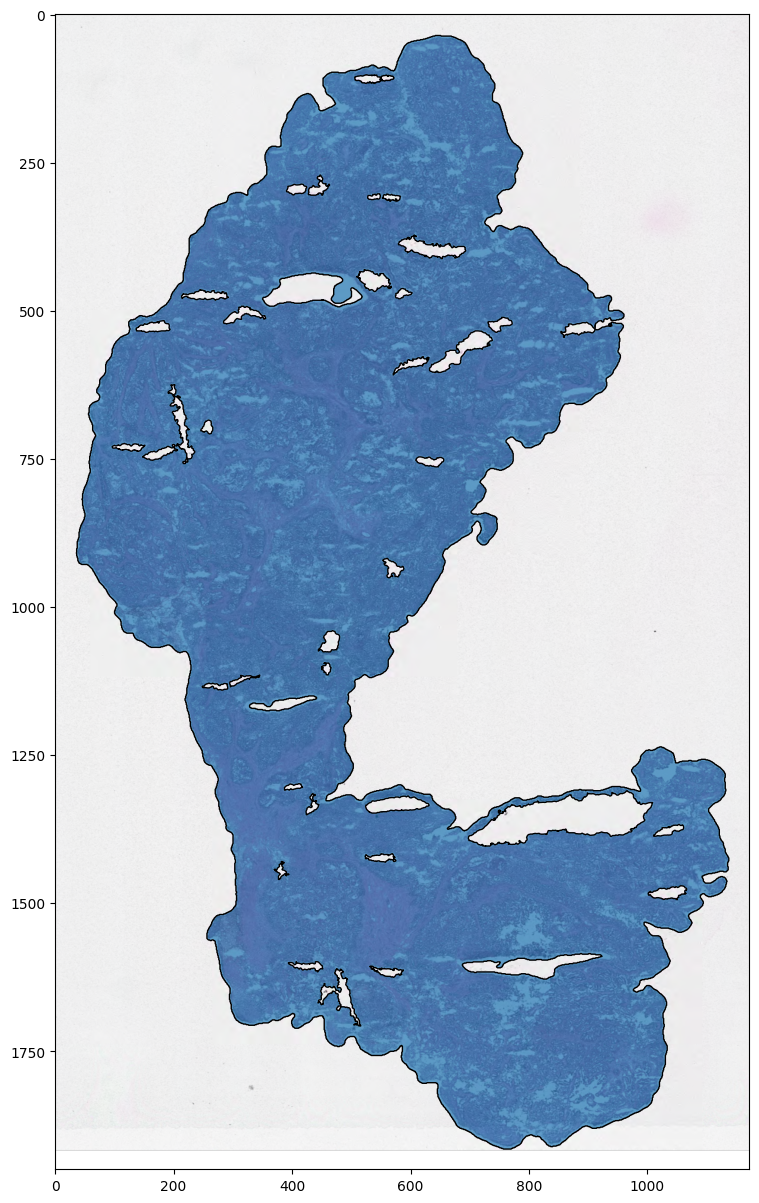

In [8]:
ret = hsf.plot_shapes_onto_tissue(unb_tissue_poly, unb_image_location, unb_tissue_poly)

# Parameter Sweeps

### Parameters
- `maximum_micrometers_squared`
    - variation will show higher yields with larger collectable regions, at the cost of less spatial resolution and probable peeling of the tissue
- `minimum_micrometers_between_shapes`
    - varation will most likely show higher yields with more slices, at the cost of taking a longer time to compute
- `n_slices_to_check`
    - varation will probably show higher yields with more slices, at the cost of taking a longer time to compute

Kept constant: 
- `minimum_micrometers_squared`
    - would show higher yields as it is decreased. (laser width, or ablation size, should be known, as the laser may just be ablating the entire region which would be collected)
- `simplify`
    - the simplification method, or its tolerances, should be decided based on the use case (single cell will require tighter tolerances, or no simplificiation at all, compared to whole slide collections)

### Collected metrics
- `yield_p`
    - percentage of original mask which would actually be collected (assuming a laser size of 0)
- `calculation_time`
    - time taken (wall time) to calculate the regions for collection

In [9]:
def get_yield(original_mask, new_mask):
    return 1 - ((original_mask - new_mask).area / original_mask.area)

In [10]:
maximum_mm_squared_parameters = [1000*1000, 900*900, 800*800, 700*700, 600*600, 500*500, 400*400, 300*300, 250*250, 200*200]
minimum_mm_between_shapes_parameters = [60, 50, 40, 30, 20]
n_slices_to_check_parameters = [3, 5, 7, 9, 11, 13]

## Tumor Mask

In [11]:
original_mask_name = "tumor-mask-test"

metrics = {}


# get the mask we are working with
mask_poly = tumor_poly
framing_poly = tissue_poly
img_loc = image_location

# make a folder for figures
current_out_dir = out_dir / original_mask_name
current_out_dir.mkdir(exist_ok=True)

In [12]:
for max_mm in maximum_mm_squared_parameters:
    for min_mm in minimum_mm_between_shapes_parameters:
        for n_slice in n_slices_to_check_parameters:
            metrics_key = f"{max_mm},{min_mm},{n_slice}"
            print(metrics_key)
            if not (out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl").exists():
                metrics[metrics_key] = {}

                start = time.time() # for collecting wall time

                to_collect = hsf.make_shapes_lmdable(img_loc, mask_poly,
                                        minimum_micrometers_squared=100*100,
                                        maximum_micrometers_squared=max_mm,
                                        minimum_micrometers_between_shapes=min_mm,
                                        n_slices_to_check=n_slice,
                                        verbose=False)

                calculation_time = time.time() - start
                
                yield_p = get_yield(mask_poly, to_collect)

                metrics[metrics_key] = dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                )
                
                print(f"{yield_p=},{calculation_time=}")

                # save plot
                stuff = hsf.plot_shapes_onto_tissue({1: mask_poly - to_collect, 0: to_collect}, img_loc, framing_poly, cmap='bwr')
                plt.title(metrics_key)
                plt.savefig(current_out_dir / (metrics_key + ".png"), bbox_inches='tight')
                plt.close()

                pd.to_pickle(dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                ), out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")
            else:
                metrics[metrics_key] = pd.read_pickle(out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")

1000000,60,3
1000000,60,5
1000000,60,7
1000000,60,9
1000000,60,11
1000000,60,13
1000000,50,3
1000000,50,5
1000000,50,7
1000000,50,9
1000000,50,11
1000000,50,13
1000000,40,3
1000000,40,5
1000000,40,7
1000000,40,9
1000000,40,11
1000000,40,13
1000000,30,3
1000000,30,5
1000000,30,7
1000000,30,9
1000000,30,11
1000000,30,13
1000000,20,3
1000000,20,5
1000000,20,7
1000000,20,9
1000000,20,11
1000000,20,13
810000,60,3
810000,60,5
810000,60,7
810000,60,9
810000,60,11
810000,60,13
810000,50,3
810000,50,5
810000,50,7
810000,50,9
810000,50,11
810000,50,13
810000,40,3
810000,40,5
810000,40,7
810000,40,9
810000,40,11
810000,40,13
810000,30,3
810000,30,5
810000,30,7
810000,30,9
810000,30,11
810000,30,13
810000,20,3
810000,20,5
810000,20,7
810000,20,9
810000,20,11
810000,20,13
640000,60,3
640000,60,5
640000,60,7
640000,60,9
640000,60,11
640000,60,13
640000,50,3
640000,50,5
640000,50,7
640000,50,9
640000,50,11
640000,50,13
640000,40,3
640000,40,5
640000,40,7
640000,40,9
640000,40,11
640000,40,13
640000,3

In [13]:
# save metrics as a combined pickle
pd.to_pickle(metrics, out_dir / f"{original_mask_name}_metrics.pkl")

## Tissue Mask (sample with tumor mask)

In [14]:
original_mask_name = "tissue-mask-test"

metrics = {}

# get the mask we are working with
mask_poly = tissue_poly
framing_poly = tissue_poly
img_loc = image_location

# make a folder for figures
current_out_dir = out_dir / original_mask_name
current_out_dir.mkdir(exist_ok=True)

In [15]:
for max_mm in maximum_mm_squared_parameters:
    for min_mm in minimum_mm_between_shapes_parameters:
        for n_slice in n_slices_to_check_parameters:
            metrics_key = f"{max_mm},{min_mm},{n_slice}"
            print(metrics_key)
            if not (out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl").exists():
                metrics[metrics_key] = {}

                start = time.time() # for collecting wall time

                to_collect = hsf.make_shapes_lmdable(img_loc, mask_poly,
                                        minimum_micrometers_squared=100*100,
                                        maximum_micrometers_squared=max_mm,
                                        minimum_micrometers_between_shapes=min_mm,
                                        n_slices_to_check=n_slice,
                                        verbose=False)

                calculation_time = time.time() - start
                
                yield_p = get_yield(mask_poly, to_collect)

                metrics[metrics_key] = dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                )
                
                print(f"{yield_p=},{calculation_time=}")

                # save plot
                stuff = hsf.plot_shapes_onto_tissue({1: mask_poly - to_collect, 0: to_collect}, img_loc, framing_poly, cmap='bwr')
                plt.title(metrics_key)
                plt.savefig(current_out_dir / (metrics_key + ".png"), bbox_inches='tight')
                plt.close()

                pd.to_pickle(dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                ), out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")
            else:
                metrics[metrics_key] = pd.read_pickle(out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")

1000000,60,3
1000000,60,5
1000000,60,7
1000000,60,9
1000000,60,11
1000000,60,13
1000000,50,3
1000000,50,5
1000000,50,7
1000000,50,9
1000000,50,11
1000000,50,13
1000000,40,3
1000000,40,5
1000000,40,7
1000000,40,9
1000000,40,11
1000000,40,13
1000000,30,3
1000000,30,5
1000000,30,7
1000000,30,9
1000000,30,11
1000000,30,13
1000000,20,3
1000000,20,5
1000000,20,7
1000000,20,9
1000000,20,11
1000000,20,13
810000,60,3
810000,60,5
810000,60,7
810000,60,9
810000,60,11
810000,60,13
810000,50,3
810000,50,5
810000,50,7
810000,50,9
810000,50,11
810000,50,13
810000,40,3
810000,40,5
810000,40,7
810000,40,9
810000,40,11
810000,40,13
810000,30,3
810000,30,5
810000,30,7
810000,30,9
810000,30,11
810000,30,13
810000,20,3
810000,20,5
810000,20,7
810000,20,9
810000,20,11
810000,20,13
640000,60,3
640000,60,5
640000,60,7
640000,60,9
640000,60,11
640000,60,13
640000,50,3
640000,50,5
640000,50,7
640000,50,9
640000,50,11
640000,50,13
640000,40,3
640000,40,5
640000,40,7
640000,40,9
640000,40,11
640000,40,13
640000,3

In [16]:
# save metrics as a pickle
pd.to_pickle(metrics, out_dir / f"{original_mask_name}_metrics.pkl")

## Tissue Mask ('unbiased' sample)

In [17]:
original_mask_name = "unb-tissue-mask-test"

metrics = {}

# get the mask we are working with
mask_poly = unb_tissue_poly
framing_poly = unb_tissue_poly
img_loc = unb_image_location

# make a folder for figures
current_out_dir = out_dir / original_mask_name
current_out_dir.mkdir(exist_ok=True)

In [18]:
for max_mm in maximum_mm_squared_parameters:
    for min_mm in minimum_mm_between_shapes_parameters:
        for n_slice in n_slices_to_check_parameters:
            metrics_key = f"{max_mm},{min_mm},{n_slice}"
            print(metrics_key)
            if not (out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl").exists():
                metrics[metrics_key] = {}

                start = time.time() # for collecting wall time

                to_collect = hsf.make_shapes_lmdable(img_loc, mask_poly,
                                        minimum_micrometers_squared=100*100,
                                        maximum_micrometers_squared=max_mm,
                                        minimum_micrometers_between_shapes=min_mm,
                                        n_slices_to_check=n_slice,
                                        verbose=False)

                calculation_time = time.time() - start
                
                yield_p = get_yield(mask_poly, to_collect)

                metrics[metrics_key] = dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                )
                
                print(f"{yield_p=},{calculation_time=}")

                # save plot
                stuff = hsf.plot_shapes_onto_tissue({1: mask_poly - to_collect, 0: to_collect}, img_loc, framing_poly, cmap='bwr')
                plt.title(metrics_key)
                plt.savefig(current_out_dir / (metrics_key + ".png"), bbox_inches='tight')
                plt.close()

                pd.to_pickle(dict(
                    yield_p=yield_p,
                    calculation_time=calculation_time,
                    maximum_µm_squared=max_mm,
                    minimum_µm_between_shapes=min_mm,
                    n_slices=n_slice
                ), out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")
            else:
                metrics[metrics_key] = pd.read_pickle(out_dir / f"{original_mask_name}/{metrics_key}_metrics.pkl")

1000000,60,3
1000000,60,5
1000000,60,7
1000000,60,9
1000000,60,11
1000000,60,13
1000000,50,3
1000000,50,5
1000000,50,7
1000000,50,9
1000000,50,11
1000000,50,13
1000000,40,3
1000000,40,5
1000000,40,7
1000000,40,9
1000000,40,11
1000000,40,13
1000000,30,3
1000000,30,5
1000000,30,7
1000000,30,9
1000000,30,11
1000000,30,13
1000000,20,3
1000000,20,5
1000000,20,7
1000000,20,9
1000000,20,11
1000000,20,13
810000,60,3
810000,60,5
810000,60,7
810000,60,9
810000,60,11
810000,60,13
810000,50,3
810000,50,5
810000,50,7
810000,50,9
810000,50,11
810000,50,13
810000,40,3
810000,40,5
810000,40,7
810000,40,9
810000,40,11
810000,40,13
810000,30,3
810000,30,5
810000,30,7
810000,30,9
810000,30,11
810000,30,13
810000,20,3
810000,20,5
810000,20,7
810000,20,9
810000,20,11
810000,20,13
640000,60,3
640000,60,5
640000,60,7
640000,60,9
640000,60,11
640000,60,13
640000,50,3
640000,50,5
640000,50,7
640000,50,9
640000,50,11
640000,50,13
640000,40,3
640000,40,5
640000,40,7
640000,40,9
640000,40,11
640000,40,13
640000,3

In [19]:
# save metrics as a pickle
pd.to_pickle(metrics, out_dir / f"{original_mask_name}_metrics.pkl")

# Analysis

How does yield change in response to the change in number of slices checked, the width between the shapes, and the maximum shape size?

In [20]:
original_mask_names = ["tumor-mask-test", "tissue-mask-test", "unb-tissue-mask-test"]

In [21]:
mask_name = original_mask_names[0]

df = pd.DataFrame(pd.read_pickle(out_dir / f"{mask_name}_metrics.pkl"))
df = df.T.astype(float)
df.head()
df = df.reset_index(drop=True)
df['mask_name'] = mask_name


mask_name = original_mask_names[1]

df1 = pd.DataFrame(pd.read_pickle(out_dir / f"{mask_name}_metrics.pkl"))
df1 = df1.T.astype(float)
df1 = df1.reset_index(drop=True)
df1['mask_name'] = mask_name

df = pd.concat([df, df1])

mask_name = original_mask_names[2]

df1 = pd.DataFrame(pd.read_pickle(out_dir / f"{mask_name}_metrics.pkl"))
df1 = df1.T.astype(float)
df1 = df1.reset_index(drop=True)
df1['mask_name'] = mask_name

df = pd.concat([df, df1])

|2026-04-24|18:50:20.726| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:20.726| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:20.776| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:20.776| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'assumed yield compared with different variables')

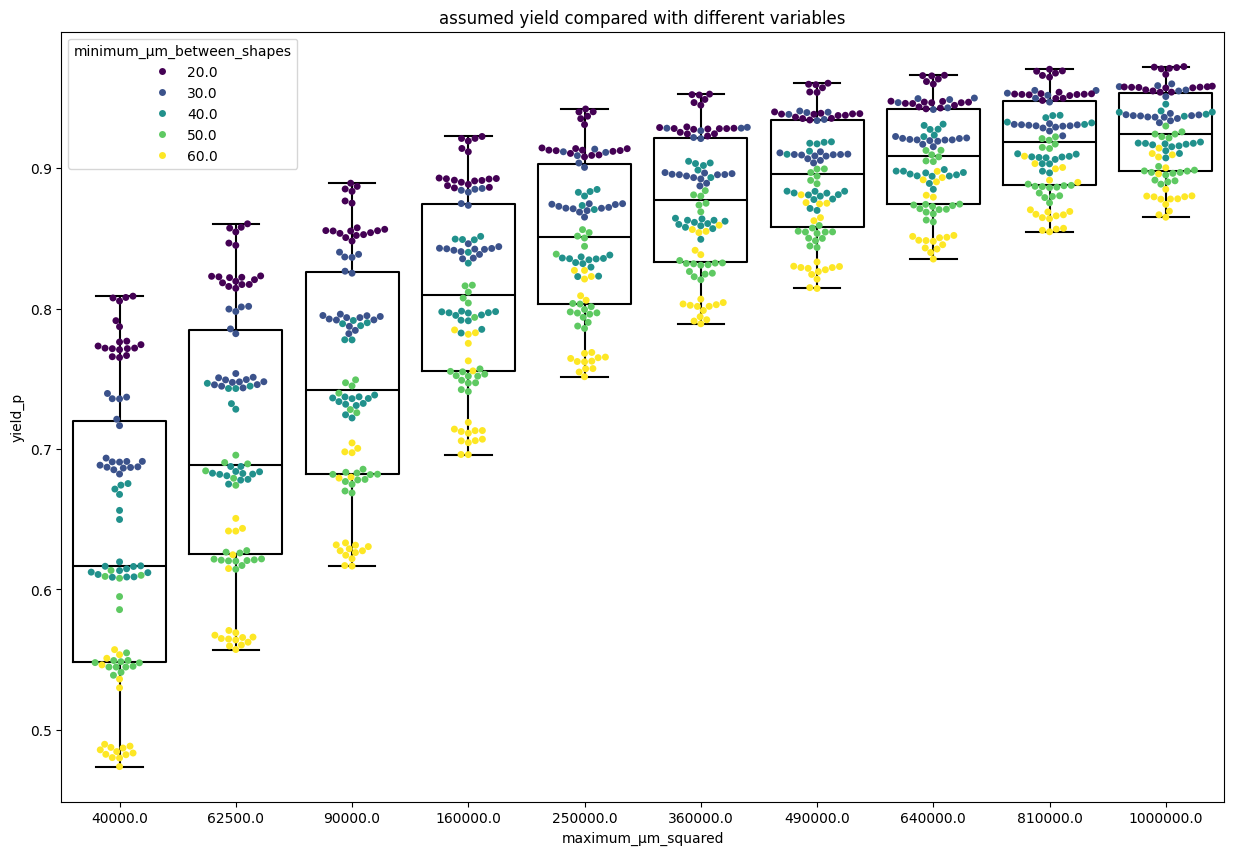

In [22]:
# install seaborn with 
# python -m pip install seaborn
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='maximum_μm_squared', y='yield_p', fill=False, color='black')
sns.swarmplot(data=df, x='maximum_μm_squared', y='yield_p', hue='minimum_μm_between_shapes', dodge=False, palette='viridis')
plt.title('assumed yield compared with different variables')

|2026-04-24|18:50:21.580| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


|2026-04-24|18:50:21.581| [WARNING] C:\Users\jschaaf25\AppData\Local\Temp\ipykernel_4092\2432127002.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(data=df, x='n_slices', y='yield_p', hue='mask_name', fill=False, color='black')



|2026-04-24|18:50:21.586| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:21.648| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:21.652| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'yield by increasing slices')

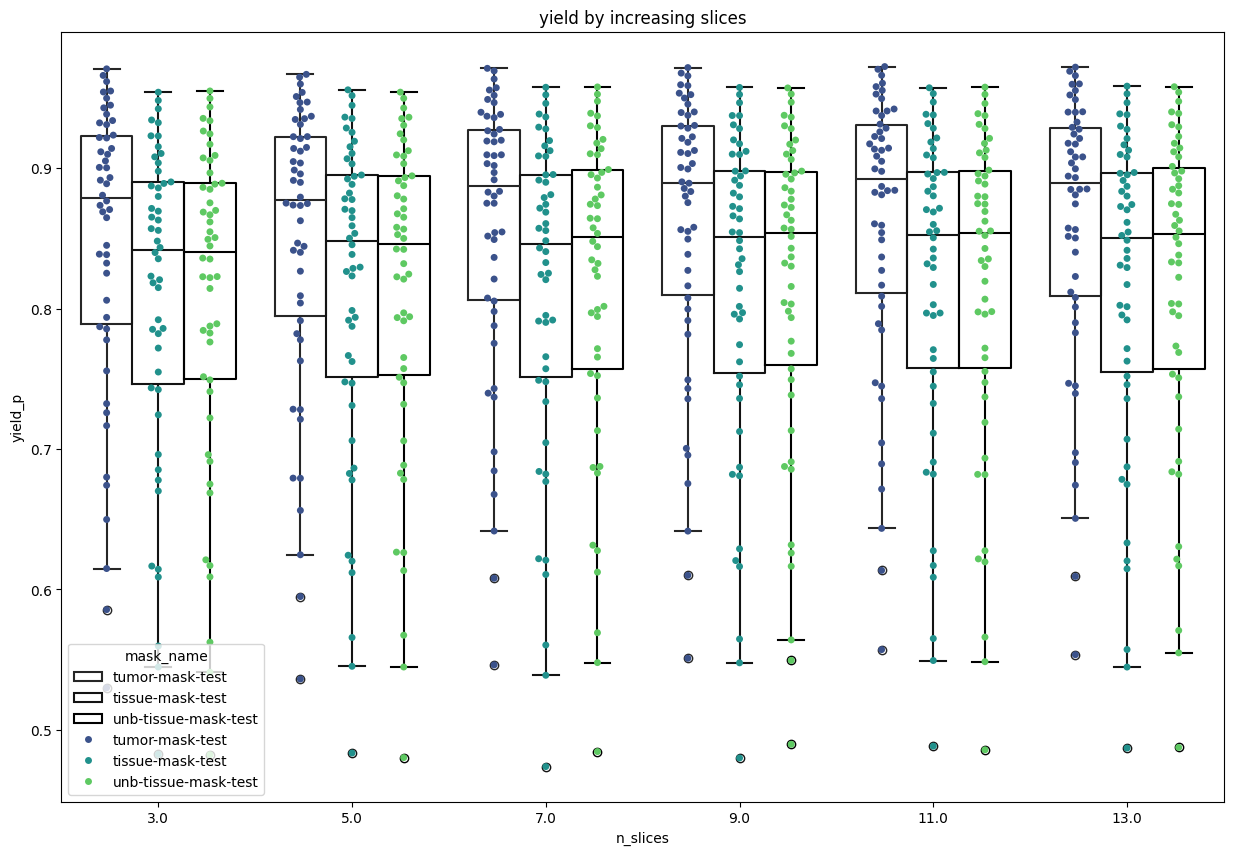

In [23]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='n_slices', y='yield_p', hue='mask_name', fill=False, color='black')

sns.swarmplot(data=df, x='n_slices', y='yield_p', hue='mask_name', dodge=True, palette='viridis')
plt.title('yield by increasing slices')

|2026-04-24|18:50:22.447| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


|2026-04-24|18:50:22.447| [WARNING] C:\Users\jschaaf25\AppData\Local\Temp\ipykernel_4092\2641363023.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.boxplot(data=df, x='n_slices', y='calculation_time', hue='mask_name',  fill=False, color='black')



|2026-04-24|18:50:22.454| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:22.518| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:22.518| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'calculation time by increasing slices')

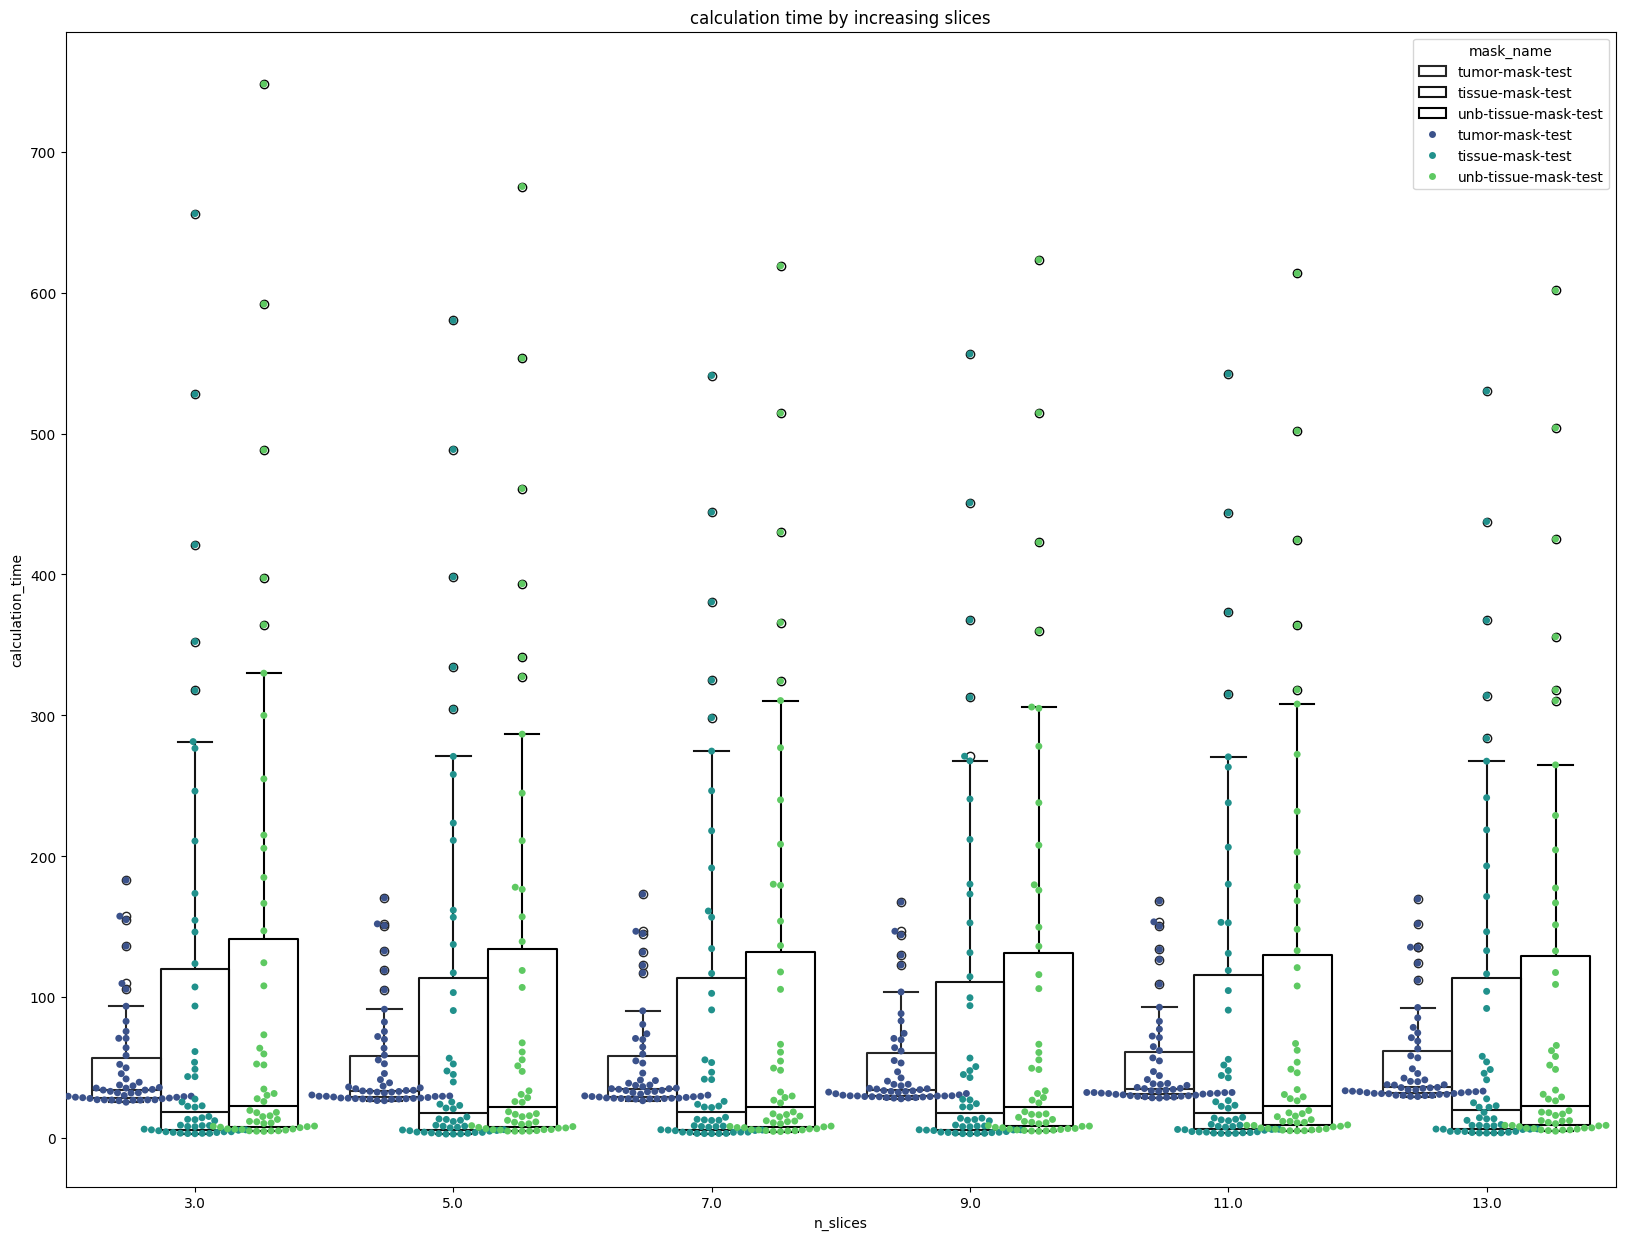

In [24]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df, x='n_slices', y='calculation_time', hue='mask_name',  fill=False, color='black')

sns.swarmplot(data=df, x='n_slices', y='calculation_time', hue='mask_name', dodge=True, palette='viridis')
plt.title('calculation time by increasing slices')

Text(0.5, 1.0, 'calculation time by yield')

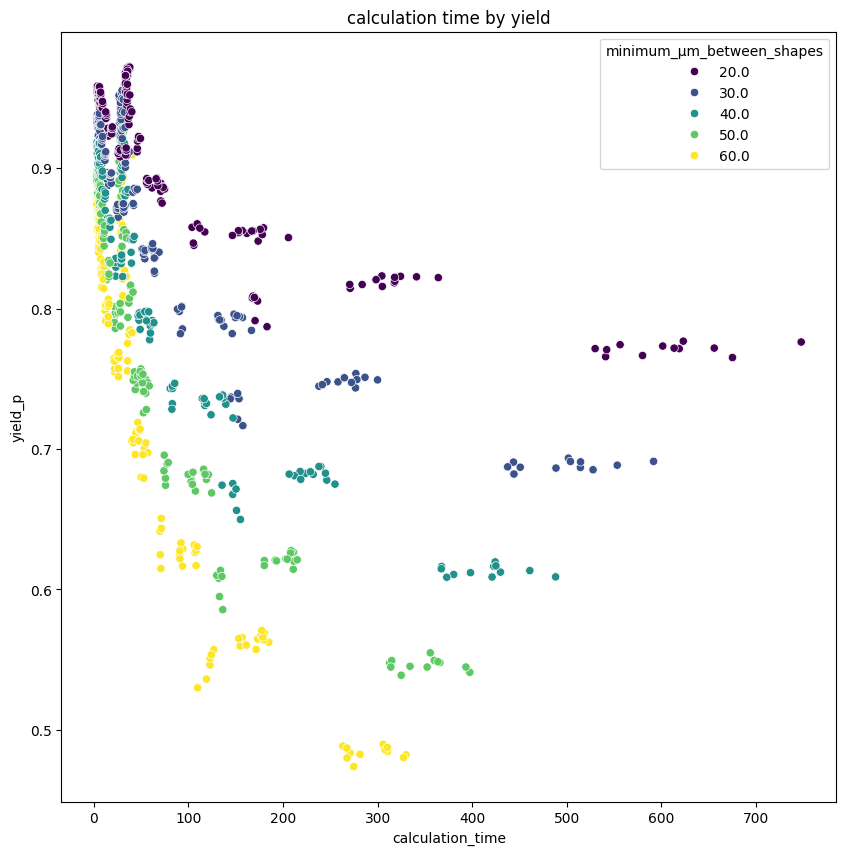

In [25]:
plt.figure(figsize=(10, 10))
#sns.boxplot(data=df, x='calculation_time', y='minimum_μm_between_shapes', hue='mask_name',  fill=False, color='black')

sns.scatterplot(data=df, x='calculation_time', y='yield_p', hue='minimum_μm_between_shapes', palette='viridis')
plt.title('calculation time by yield')

Text(0.5, 1.0, 'calculation time by yield')

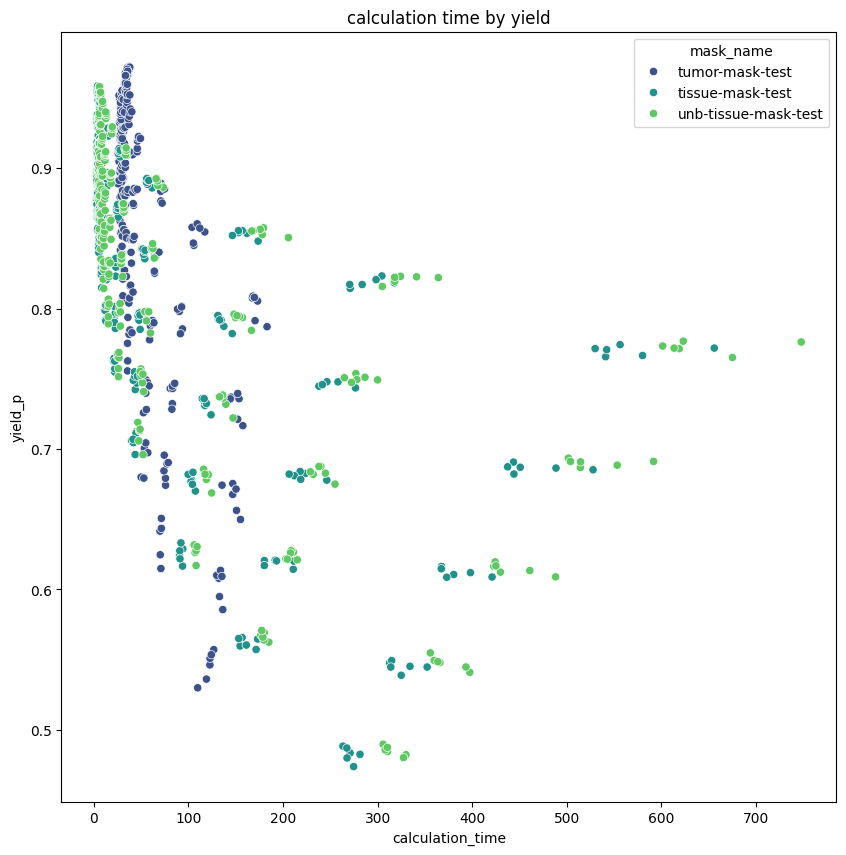

In [26]:
plt.figure(figsize=(10, 10))
#sns.boxplot(data=df, x='calculation_time', y='minimum_μm_between_shapes', hue='mask_name',  fill=False, color='black')

sns.scatterplot(data=df, x='calculation_time', y='yield_p', hue='mask_name', palette='viridis')
plt.title('calculation time by yield')

|2026-04-24|18:50:23.928| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:23.930| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:23.972| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
|2026-04-24|18:50:23.977| [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


|2026-04-24|18:50:24.107| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.171| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.230| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.295| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-package

Text(0.5, 1.0, 'calculation time by max µm squared')

|2026-04-24|18:50:24.636| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.700| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.824| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

|2026-04-24|18:50:24.893| [WARNING] c:\Users\jschaaf25\AppData\Local\miniconda3\envs\shapeuplmd\lib\site-package

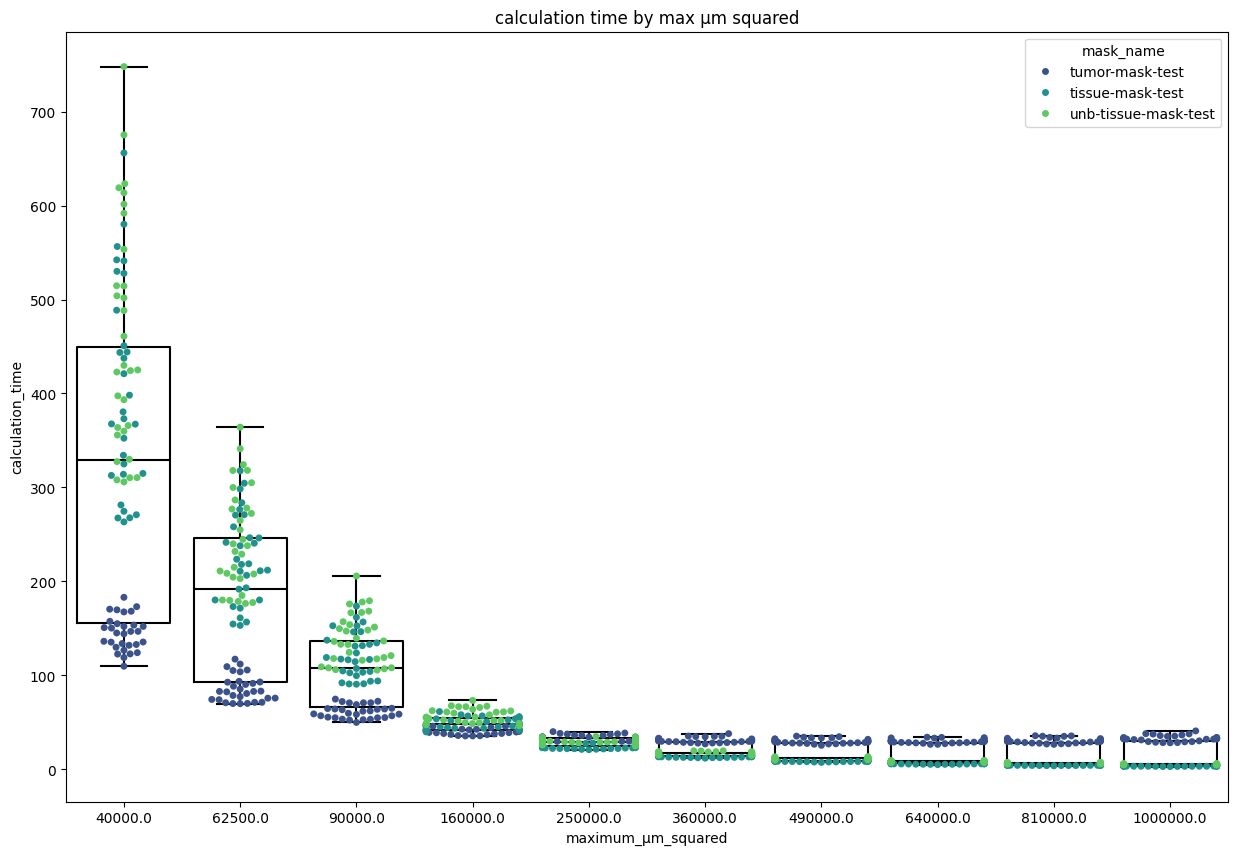

In [27]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='maximum_μm_squared', y='calculation_time', fill=False, color='black')

sns.swarmplot(data=df, x='maximum_μm_squared', y='calculation_time', hue='mask_name', palette='viridis')
plt.title('calculation time by max µm squared')